# XGBoost Time Series Forecasting
### Goal: Use XGBoost to forecast daily unit sales

---

### What is XGBoost?

XGBoost stands for **Extreme Gradient Boosting**.  
It is a machine learning model that builds hundreds of small decision trees,  
each one learning from the mistakes of the one before it.

Unlike ARIMA or Holt-Winters, XGBoost **does not understand time on its own**.  
However, because our dataset already has time-based features engineered in  
(lag values, rolling averages, calendar flags), we can pass them directly  
to XGBoost without any extra steps.

### Dataset
**timeseries_with_features.csv** which are daily unit sales from January 2013 to March 2014.  
All features were already created in the Feature Engineering notebook.

---
## Step 1 — Install and Import Libraries

In [ ]:
# Install XGBoost if not already installed
# ! pip install xgboost

In [9]:
# Import packages
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from xgboost import plot_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("All libraries imported successfully!")

All libraries imported successfully!


---
## Step 2 — Set the Data Folder

In [10]:
# Change this to the folder where your CSV file is saved
DATA_DIR = r'C:\Users\tthem\timeseries-april\data'

print("Looking for data in:", os.path.abspath(DATA_DIR))

Looking for data in: C:\Users\tthem\timeseries-april\data


---
## Step 3 — Load the Dataset

In [11]:
# Load the feature-engineered dataset
df = pd.read_csv(os.path.join(DATA_DIR, 'timeseries_with_features.csv'))

# Convert date column to datetime and set as index
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
df = df.sort_index()

# Drop rows with NaN values (caused by lag features at the start of the series)
df = df.dropna()

print("Dataset loaded!")
print("Shape:", df.shape)
print("Date range:", df.index.min().date(), "to", df.index.max().date())
print()
print("First 5 rows:")
print(df.head())

Dataset loaded!
Shape: (422, 24)
Date range: 2013-02-01 to 2014-03-31

First 5 rows:
            unit_sales  dcoilwtico  is_national_holiday  is_regional_holiday  \
date                                                                           
2013-02-01       401.0   97.460000                    0                    0   
2013-02-02       775.0   97.043333                    0                    0   
2013-02-03       855.0   96.626667                    0                    0   
2013-02-04       411.0   96.210000                    0                    0   
2013-02-05       272.0   96.680000                    0                    0   

            is_local_holiday  year  month  day  dayofweek  quarter  ...  \
date                                                                ...   
2013-02-01                 0  2013      2    1          4        1  ...   
2013-02-02                 0  2013      2    2          5        1  ...   
2013-02-03                 0  2013      2    3        

---
## Step 4 — Explore the Data

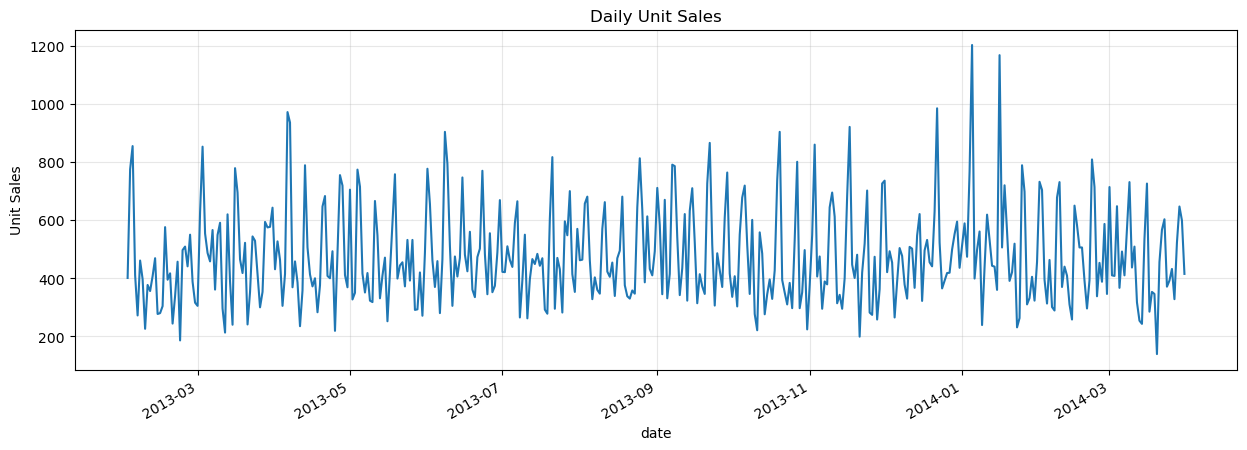

In [12]:
# Plot unit_sales over time
df['unit_sales'].plot(figsize=(15, 5), title='Daily Unit Sales')
plt.ylabel('Unit Sales')
plt.grid(True, alpha=0.3)
plt.show()

---
## Step 5 — Train / Test Split

We split the data by time — everything **before** January 1, 2014 is used for training,  
and everything **from** January 1, 2014 onwards is used for testing.

We never split time series data randomly — the model must always train on the past and predict the future.

In [13]:
split_date = '01-Jan-2014'

df_train = df.loc[df.index < split_date].copy()   # Train on past data
df_test  = df.loc[df.index >= split_date].copy()  # Test on future data

print("Training rows:", len(df_train))
print("  From:", df_train.index.min().date(), "to", df_train.index.max().date())
print()
print("Test rows:", len(df_test))
print("  From:", df_test.index.min().date(), "to", df_test.index.max().date())

Training rows: 333
  From: 2013-02-01 to 2013-12-31

Test rows: 89
  From: 2014-01-02 to 2014-03-31


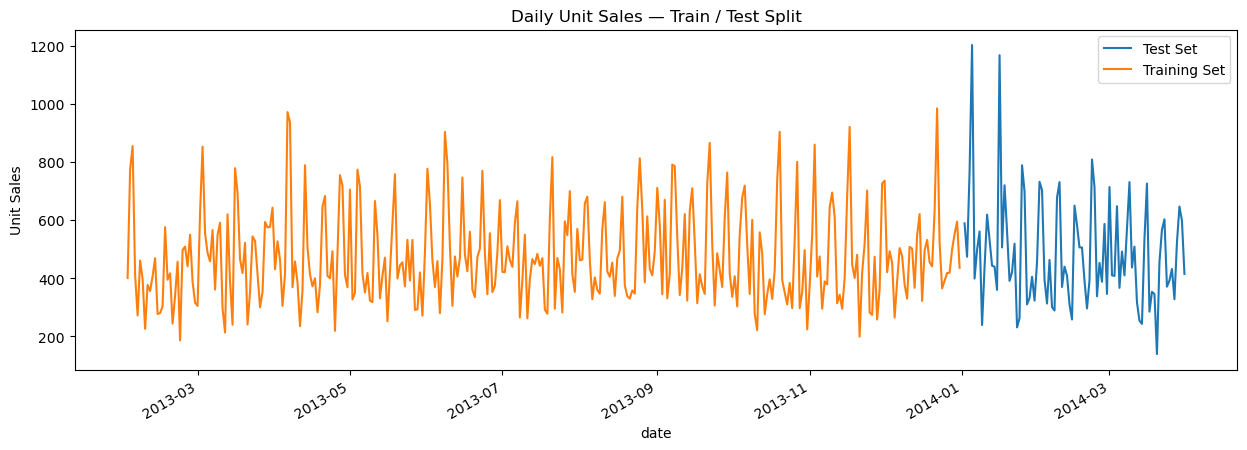

In [14]:
# Visualise the train / test split

test_renamed  = df_test[['unit_sales']].rename(columns={'unit_sales': 'Test Set'})
train_renamed = df_train[['unit_sales']].rename(columns={'unit_sales': 'Training Set'})

combined_data = test_renamed.join(train_renamed, how='outer')

combined_data.plot(
    figsize=(15, 5),
    title='Daily Unit Sales — Train / Test Split'
)
plt.ylabel('Unit Sales')
plt.show()

---
## Step 6 — Define Features and Target

Because our CSV already contains all the engineered features  
(lag values, rolling averages, calendar flags, oil price, holidays),  
we do not need a `create_features()` function.  
We simply select which columns to use as inputs to the model.

In [15]:
# Define the feature columns (inputs to XGBoost)
# These are all the columns the model is allowed to learn from

features = [
    # Calendar features
    'year', 'month', 'day', 'dayofweek', 'quarter', 'week_of_year',
    'is_weekend', 'is_month_start', 'is_month_end',
    # Lag features — past sales values
    'lag_1', 'lag_7', 'lag_14', 'lag_30',
    # Rolling window features — recent trends
    'rolling_7d_mean', 'rolling_14d_mean', 'rolling_30d_mean', 'rolling_7d_std',
    # Oil price features
    'dcoilwtico', 'oil_lag_1', 'oil_rolling_7d_mean',
    # Holiday flags
    'is_national_holiday', 'is_regional_holiday', 'is_local_holiday',
]

# Target column (what we want to predict)
target = 'unit_sales'

# Split into X (features) and y (target) for train and test
X_train = df_train[features]
y_train = df_train[target]

X_test = df_test[features]
y_test = df_test[target]

print("Features:", len(features))
print("Training samples:", len(X_train))
print("Test samples:    ", len(X_test))

Features: 23
Training samples: 333
Test samples:     89


---
## Step 7 — Build and Train the XGBoost Model

**Key parameters:**
- `n_estimators` — the number of decision trees to build
- `early_stopping_rounds` — if the model stops improving after 50 trees, training stops automatically

In [16]:
# Sets up and trains an XGBoost regression model
reg = xgb.XGBRegressor(n_estimators=1000, early_stopping_rounds=50)

# n_estimators = number of decision trees
# early_stopping_rounds = if training does not improve after 50x, training stops

# Trains the model with monitoring
reg.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

print("Model training complete!")

Model training complete!


---
## Step 8 — Feature Importance

Feature importance tells us **which features the model relied on most** when making predictions.

It is calculated by how often each feature is used to split data in the decision trees  
and how much each feature improves predictions when used.

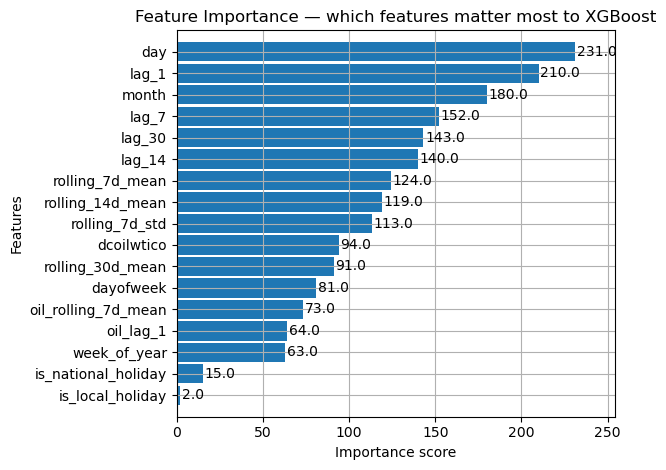

In [17]:
# Visualise which features the model considers most important
plot_importance(reg, height=0.9)
plt.title('Feature Importance — which features matter most to XGBoost')
plt.tight_layout()
plt.show()

---
## Step 9 — Forecast on the Test Set

In [18]:
# Generate predictions and combine all data for analysis
df_test['MW_Prediction'] = reg.predict(X_test)   # Add predictions column
df_all = pd.concat([df_test, df_train])           # Combine test and training sets
df_all = df_all.sort_index()                      # Sort into chronological order

print("Predictions added.")
print("Combined dataset shape:", df_all.shape)

Predictions added.
Combined dataset shape: (422, 25)


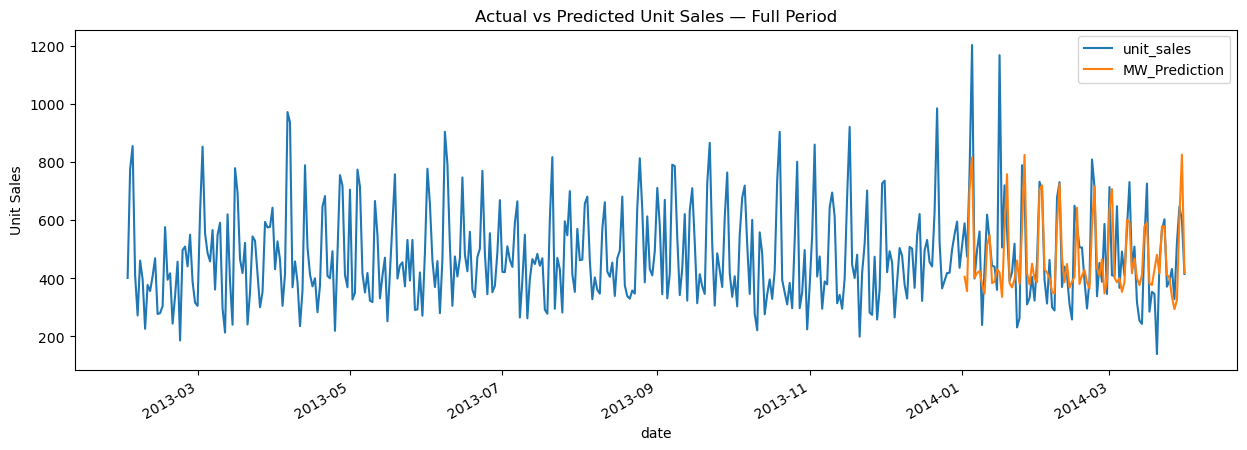

In [19]:
# Compare actual unit sales with model predictions — full period
df_all[['unit_sales', 'MW_Prediction']].plot(figsize=(15, 5))
plt.title('Actual vs Predicted Unit Sales — Full Period')
plt.ylabel('Unit Sales')
plt.show()

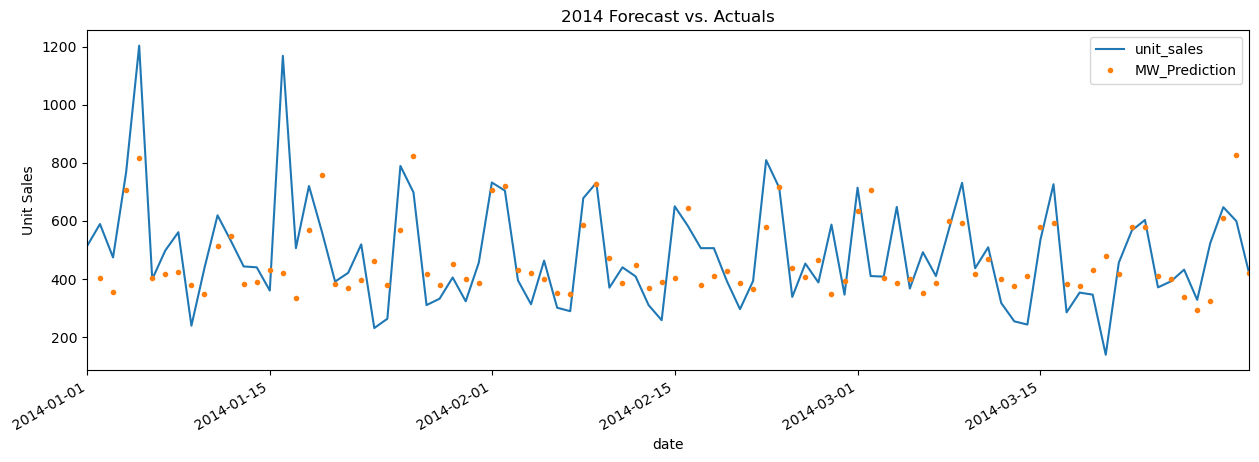

In [20]:
# Zoom into the test period only

fig, ax = plt.subplots(figsize=(15, 5))

df_all[['unit_sales', 'MW_Prediction']].plot(ax=ax, style=['-', '.'])
ax.set_xbound(lower='01-01-2014', upper='03-31-2014')  # Focus on test period
plt.title('2014 Forecast vs. Actuals')
plt.ylabel('Unit Sales')
plt.show()

---
## Step 10 — Worst and Best Predicted Days

We calculate how far off the model was each day and identify  
the days where it performed best and worst.

In [21]:
# Raw error — difference between actual and predicted
# Positive = model under-predicted, Negative = model over-predicted
df_test['error'] = df_test['unit_sales'] - df_test['MW_Prediction']

# Absolute error — always positive, measures size of error regardless of direction
df_test['abs_error'] = df_test['error'].apply(np.abs)

print("Error columns added.")
print()
print("Error summary:")
print(df_test[['error', 'abs_error']].describe().round(2))

Error columns added.

Error summary:
        error  abs_error
count   89.00      89.00
mean    17.30     102.65
std    146.48     105.36
min   -341.41       2.08
25%    -59.99      39.42
50%      5.29      76.81
75%     91.39     130.24
max    748.19     748.19
